In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ending_club_preprocessed2.csv', parse_dates=['issue_d', 'earliest_cr_line'])

# 1- 모델을 위해 최적화된 변수 선택 
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)
    "installment",                   # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    "annual_inc",                    # 자기보고 연소득 ($)
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_bal",                     # 리볼빙 총 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1
    "issue_d", "earliest_cr_line"
]

df = df[use_col].copy()

# 2- 파생컬럼 
df['issue_year'] = df['issue_d'].dt.year.astype(str)
df['issue_month'] = df['issue_d'].dt.month.astype(str) 
df["earliest_cr_line_year"]= pd.to_datetime(df["earliest_cr_line"]).dt.year.astype(str)

df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12) # installment_to_income (월상환부담률)
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] #  loan_to_income (대출규모 대비 소득)
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)

#숫자 잘못 처리 되었을 때 NaN 처리
new_cols = ['installment_to_income', 'loan_to_income','revol_bal_to_income']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# 생성후 Drop / "annual_inc", "revol_bal","installment" 은 개인 판단으로 고고 저는 뺄예정 
df = df.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])

print(f"전체: {len(df.columns)}")
print(f"고유: {len(set(df.columns))}") # >> 42 정상

C:\Users\gywns\AppData\Local\Temp\ipykernel_26488\1245764878.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('ending_club_preprocessed2.csv', parse_dates=['issue_d', 'earliest_cr_line'])


전체: 42
고유: 42


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_curve, auc
from catboost import CatBoostClassifier

In [5]:
# 1. 데이터 준비 (use_col 사용)
# df는 이미 전처리가 어느 정도 된 상태라고 가정합니다.
X = df.drop(columns=['target'])
y = df['target']

# 2. 범주형 변수 자동 식별
# CatBoost는 문자열(object)이나 카테고리(category) 타입을 스스로 찾아냅니다.
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. 결측치 처리
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    train_median = X_train[col].median()                    # train으로만 계산
    X_train[col] = X_train[col].fillna(train_median)       # train에 적용
    X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

## mo_sin_old_il_acct  가장 오래된 할부 계좌 이후 경과 월수
## 0 으로 
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(0) 


# mths_since_rcnt_il 가장 최근 할부 계좌(Installment Loan) 개설 이후 경과 월수
## 중앙값으로 채우기 
medi_rcnt_il = X_train["mths_since_rcnt_il"].median()
X_train["mths_since_rcnt_il"] = X_train["mths_since_rcnt_il"].fillna(medi_rcnt_il)
X_test["mths_since_rcnt_il"] = X_test["mths_since_rcnt_il"].fillna(medi_rcnt_il)

# ★train/test 이후 전처리
# dti "sub_grade" 사용해야함 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = X_train.groupby("sub_grade")["dti"].median()
X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)
    
# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

# 5) cat_features 지정 (전처리 없이 그대로 사용)
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

# #결측치 최종 검증(값 있는지 확인)
# print(X_train.isna().sum().sort_values(ascending = False).head(5))
# print(X_test.isna().sum().sort_values(ascending = False).head(5))

# 6) 모델 학습
model = CatBoostClassifier(
    auto_class_weights='Balanced',
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test) # 학습 중 검증 데이터 확인
)

# 7) 평가
proba = model.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] # 성능이 제일 잘 나오는 임계값

pred_best = (proba >= best_threshold).astype(int)

pr_auc_score = auc(recall, precision)

C:\Users\gywns\AppData\Local\Temp\ipykernel_26488\2806692513.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


0:	learn: 0.6869749	test: 0.6885008	best: 0.6885008 (0)	total: 1.02s	remaining: 13m 35s
100:	learn: 0.7099913	test: 0.7115170	best: 0.7115170 (100)	total: 1m 38s	remaining: 11m 18s
200:	learn: 0.7155967	test: 0.7163990	best: 0.7163990 (200)	total: 3m 15s	remaining: 9m 43s
300:	learn: 0.7190751	test: 0.7189777	best: 0.7189777 (300)	total: 4m 53s	remaining: 8m 6s
400:	learn: 0.7219020	test: 0.7207168	best: 0.7207168 (400)	total: 6m 29s	remaining: 6m 27s
500:	learn: 0.7240701	test: 0.7218635	best: 0.7218635 (500)	total: 8m 8s	remaining: 4m 51s
600:	learn: 0.7258568	test: 0.7226687	best: 0.7226687 (600)	total: 9m 48s	remaining: 3m 14s
700:	learn: 0.7273741	test: 0.7232464	best: 0.7232464 (700)	total: 11m 28s	remaining: 1m 37s
799:	learn: 0.7287062	test: 0.7236619	best: 0.7236619 (799)	total: 13m 7s	remaining: 0us

bestTest = 0.723661942
bestIteration = 799



사용된 최적 임계값: 0.5365
CatBoost Accuracy: 0.6967
CatBoost PR-AUC: 0.4194

[Classification Report (Threshold=0.54)]:
               precision    recall  f1-score   support

         0.0       0.88      0.71      0.79    203905
         1.0       0.36      0.62      0.45     51655

    accuracy                           0.70    255560
   macro avg       0.62      0.67      0.62    255560
weighted avg       0.78      0.70      0.72    255560



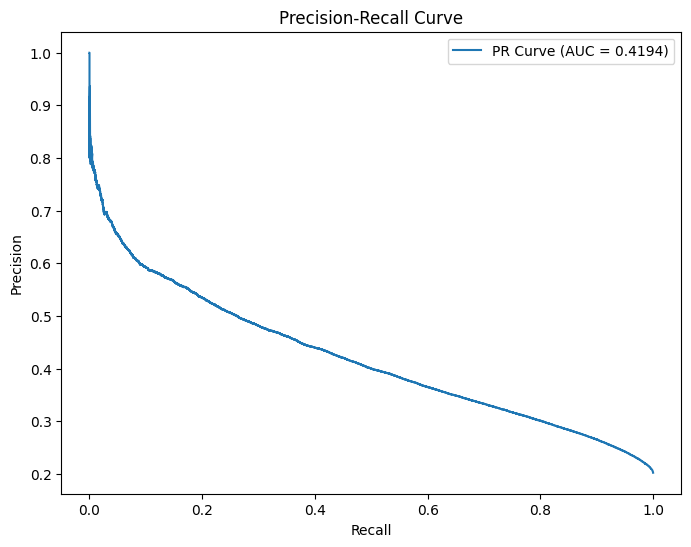

In [6]:
print(f"사용된 최적 임계값: {best_threshold:.4f}")
print(f"CatBoost Accuracy: {accuracy_score(y_test, pred_best):.4f}")
print(f"CatBoost PR-AUC: {pr_auc_score:.4f}")
print(f"\n[Classification Report (Threshold={best_threshold:.2f})]:\n", 
      classification_report(y_test, pred_best))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

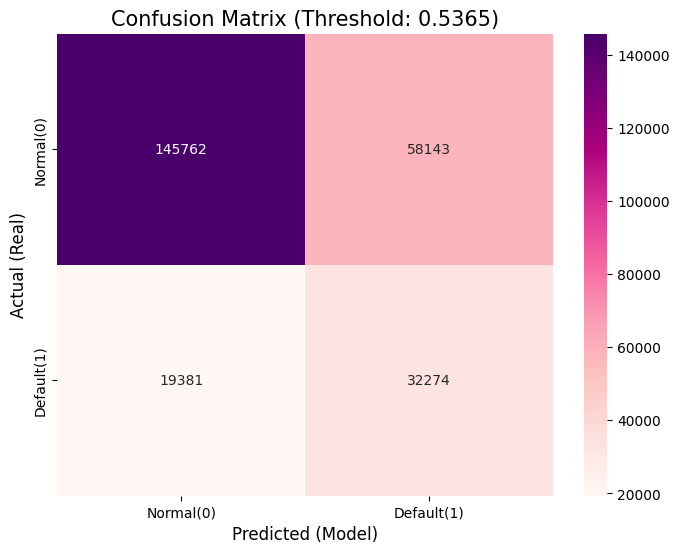


--- 혼동행렬 비율 (%) ---
[[0.57036312 0.22751213]
 [0.07583738 0.12628737]]


In [7]:
from sklearn.metrics import confusion_matrix

# 1. 최적 임계값을 적용한 최종 예측값 생성
# 만약 위에서 best_threshold를 구하지 않았다면 임의로 0.3 등을 넣어서 테스트해보세요.
final_pred = (proba >= best_threshold).astype(int)

# 2. 혼동행렬 계산
cm = confusion_matrix(y_test, final_pred)

# 3. 시각화 (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', # 연체 예측은 경고의 의미로 붉은 계열 추천
            xticklabels=['Normal(0)', 'Default(1)'], 
            yticklabels=['Normal(0)', 'Default(1)'])

plt.title(f'Confusion Matrix (Threshold: {best_threshold:.4f})', fontsize=15)
plt.xlabel('Predicted (Model)', fontsize=12)
plt.ylabel('Actual (Real)', fontsize=12)
plt.show()

# 4. 비율로도 확인하기 (전체 중 어디에 집중되어 있나?)
print("\n--- 혼동행렬 비율 (%) ---")
print(cm / cm.sum())

오른쪽 아래 (True Positive, TP): 모델이 "연체될 거야"라고 했는데 진짜로 연체한 사람입니다. 이 숫자가 클수록 우리 모델의 존재 가치가 증명됩니다.

왼쪽 아래 (False Negative, FN): 모델이 "정상이야"라고 했는데 나중에 연체해버린 사람입니다. 은행 입장에서 가장 무서운 숫자이며, 임계값을 낮춰서라도 이 숫자를 줄이는 것이 이번 프로젝트의 핵심입니다.

오른쪽 위 (False Positive, FP): 모델이 "연체 위험!"이라고 해서 대출을 안 해줬는데, 사실은 성실하게 갚을 사람입니다. 영업팀에서 싫어하겠지만, 안전을 위해 감수해야 하는 부분입니다.

왼쪽 위 (True Negative, TN): 정상인을 정상으로 잘 분류한 경우입니다.

C:\Users\gywns\AppData\Local\Temp\ipykernel_26488\1866300481.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


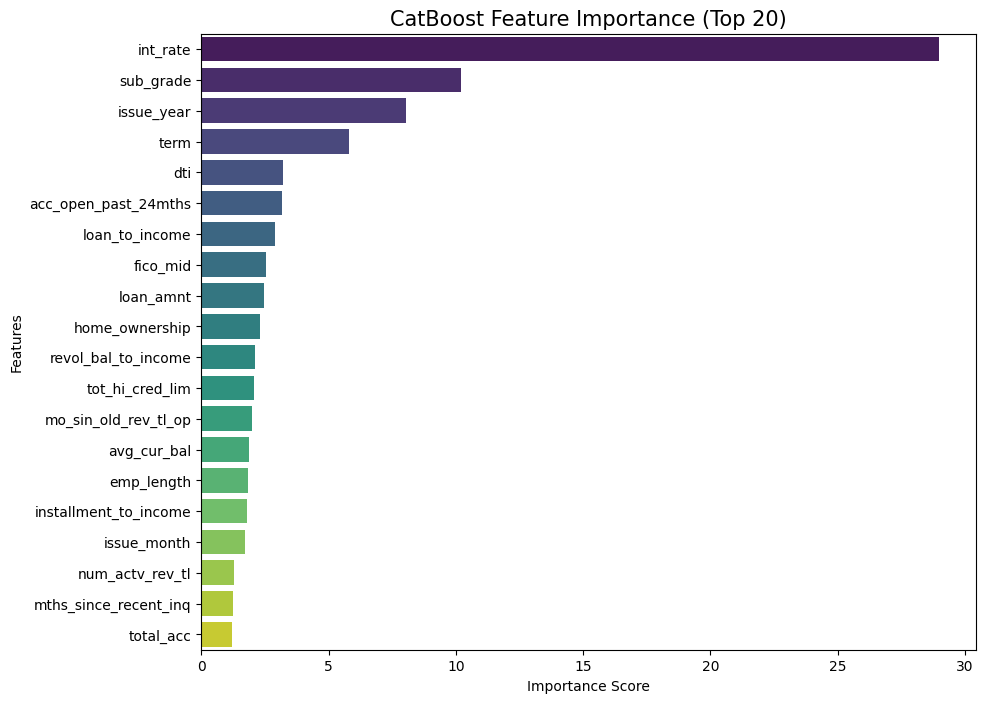

                  Feature  Importance
2                int_rate   29.000503
3               sub_grade   10.217461
5              issue_year    8.055284
1                    term    5.805943
8                     dti    3.228046
22   acc_open_past_24mths    3.159161
39         loan_to_income    2.890797
9                fico_mid    2.534963
0               loan_amnt    2.454211
7          home_ownership    2.316531
40    revol_bal_to_income    2.099165
16        tot_hi_cred_lim    2.060569
23   mo_sin_old_rev_tl_op    2.008982
11            avg_cur_bal    1.860037
6              emp_length    1.836919
38  installment_to_income    1.798459
36            issue_month    1.719351
18        num_actv_rev_tl    1.302478
27  mths_since_recent_inq    1.252373
21              total_acc    1.212346


In [8]:
# 1. 변수 중요도 데이터프레임 만들기
feature_importance = model.get_feature_importance()
feature_names = X_train.columns
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# 2. 중요도 순으로 정렬 (상위 20개만 보기)
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(20)

# 3. 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('CatBoost Feature Importance (Top 20)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 4. 수치로 확인
print(df_importance)

In [9]:
import shap
import warnings
warnings.filterwarnings('ignore')

# 1. SHAP Explainer 초기화 (CatBoost 모델 전용)
# CatBoost는 트리 기반 모델이므로 TreeExplainer를 사용합니다.
explainer = shap.TreeExplainer(model)

# 2. SHAP Value 계산 (속도를 위해 테스트셋에서 1000건 샘플링)
sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_test_sample)


c:\2생_project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# 1. SHAP 값의 절대값 평균 계산 (변수별 기여도 점수)
# shap_values는 (샘플수, 변수수) 형태이므로, 세로(axis=0)로 평균을 냅니다.
avg_shap_values = np.abs(shap_values).mean(0)

# 2. 데이터프레임 생성
df_shap_importance = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Importance': avg_shap_values
})

# 3. 중요도 순으로 정렬 (CatBoost 방식과 똑같이!)
df_shap_importance = df_shap_importance.sort_values(by='Importance', ascending=False).head(20)

# 4. 수치 확인
print(df_shap_importance)

                  Feature  Importance
2                int_rate    0.302952
1                    term    0.235573
5              issue_year    0.137092
8                     dti    0.132240
22   acc_open_past_24mths    0.111399
7          home_ownership    0.086858
3               sub_grade    0.085813
39         loan_to_income    0.082463
9                fico_mid    0.081995
27  mths_since_recent_inq    0.058571
16        tot_hi_cred_lim    0.055081
6              emp_length    0.051931
0               loan_amnt    0.051522
18        num_actv_rev_tl    0.051018
11            avg_cur_bal    0.049053
26   mths_since_recent_bc    0.043368
15         total_bc_limit    0.041302
23   mo_sin_old_rev_tl_op    0.040159
21              total_acc    0.040085
4                 purpose    0.039288


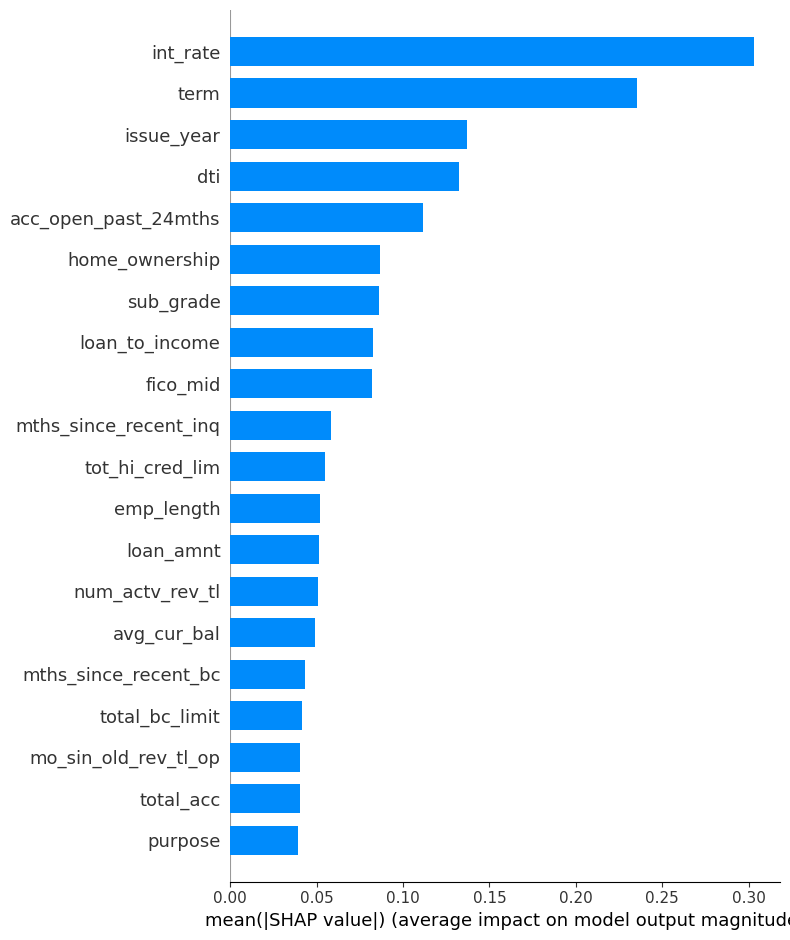

In [11]:
plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar')

"CatBoost 기본 중요도에서는 A 변수가 높지만 SHAP에서는 B 변수가 높게 나타났습니다. 이는 A 변수가 모델이 데이터를 나누는 **가이드 역할(구조적 기여)**을 많이 수행한 반면, 실제 예측 확률값을 크게 변화시키는 영향력은 B 변수가 더 강력하다는 것을 시사합니다."
--> subgrade 경우 활용해보기

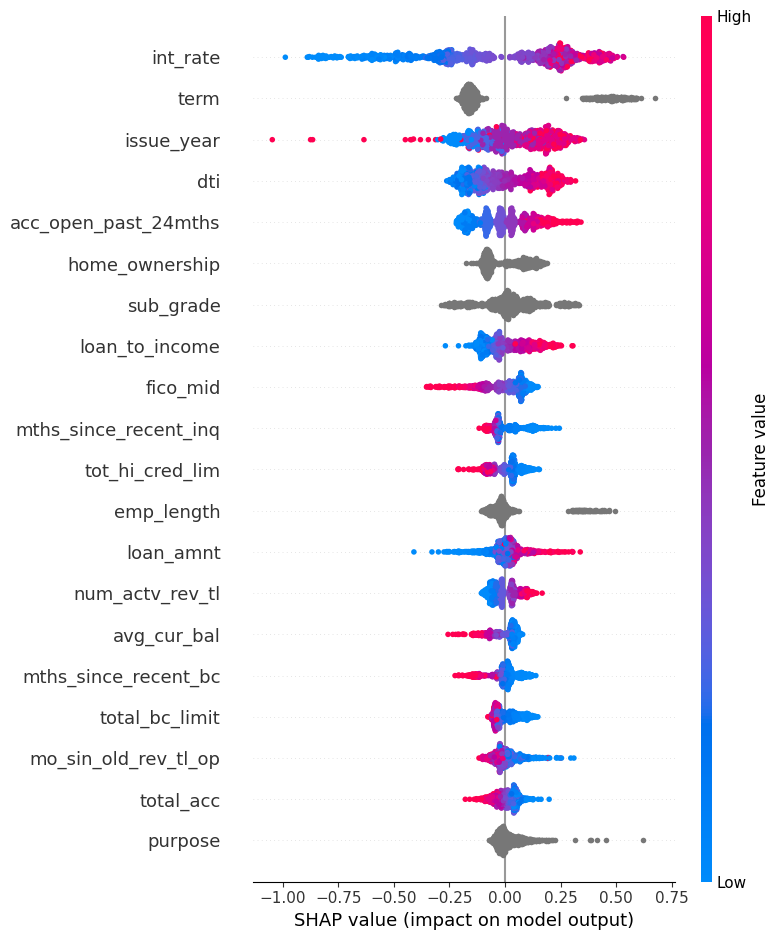

In [12]:
# 3. Summary Plot 그리기 (변수별 영향력 확인)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample)

In [13]:
from sklearn.utils import resample

# 1. 부트스트랩 반복 횟수 설정
n_iterations = 100
stats = []

for i in range(n_iterations):
    # 샘플 재추출 (중복 허용)
    X_resample = resample(X_test_sample, n_samples=500)
    # 해당 샘플에 대한 SHAP 값 계산
    shap_v = explainer.shap_values(X_resample)
    # 변수별 평균 절대값 저장
    stats.append(np.abs(shap_v).mean(0))

# 2. 결과 데이터프레임화 및 95% 신뢰구간 계산
df_stats = pd.DataFrame(stats, columns=X_test_sample.columns)
lower = df_stats.quantile(0.025) # 하위 2.5%
upper = df_stats.quantile(0.975) # 상위 97.5%

# 3. 중요도와 신뢰구간 합치기
df_conf = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Importance': np.abs(shap_values).mean(0),
    'Lower_CI': lower.values,
    'Upper_CI': upper.values
}).sort_values('Importance', ascending=False)

print(df_conf.head(10))

                  Feature  Importance  Lower_CI  Upper_CI
2                int_rate    0.302952  0.288870  0.317976
1                    term    0.235573  0.223035  0.247459
5              issue_year    0.137092  0.128270  0.147051
8                     dti    0.132240  0.126401  0.139832
22   acc_open_past_24mths    0.111399  0.106536  0.118041
7          home_ownership    0.086858  0.083684  0.089108
3               sub_grade    0.085813  0.080461  0.091636
39         loan_to_income    0.082463  0.077838  0.086830
9                fico_mid    0.081995  0.077316  0.087650
27  mths_since_recent_inq    0.058571  0.055789  0.062462


해석: 만약 특정 변수의 신뢰구간(Lower ~ Upper)이 0을 포함하지 않고 높게 형성되어 있다면, 그 변수는 통계적으로 매우 견고하게 중요한 변수라고 할 수 있습니다.

상위권 변수들의 Lower_CI (신뢰구간 하한) 수치가 0에 가깝게 붙어있는 변수가 있나요? 만약 그렇다면 그 변수는 중요도가 불안정하다는 뜻

In [14]:
from scipy.stats import pointbiserialr

# 1. 특정 변수(예: int_rate)의 SHAP 값 추출
# X_test_sample의 인덱스와 y_test의 인덱스를 맞춰야 합니다.
target_sample = y_test.loc[X_test_sample.index]

results = []
for i, col in enumerate(X_test_sample.columns):
    # SHAP 값과 실제 타겟(연체 여부) 간의 상관계수 및 p-value 계산
    corr, p_val = pointbiserialr(target_sample, shap_values[:, i])
    results.append({'Feature': col, 'Correlation': corr, 'p-value': p_val})

df_test = pd.DataFrame(results).sort_values('p-value')
# p-value가 0.05보다 작은 변수들만 출력
print(df_test[df_test['p-value'] < 0.05])

                  Feature  Correlation       p-value
2                int_rate     0.220930  1.604362e-12
3               sub_grade     0.198470  2.429452e-10
1                    term     0.152676  1.231725e-06
5              issue_year     0.148287  2.484020e-06
9                fico_mid     0.136477  1.486703e-05
7          home_ownership     0.126825  5.775752e-05
14         bc_open_to_buy     0.125112  7.277117e-05
39         loan_to_income     0.116495  2.226094e-04
38  installment_to_income     0.113595  3.190025e-04
18        num_actv_rev_tl     0.112627  3.590326e-04
15         total_bc_limit     0.108577  5.830490e-04
16        tot_hi_cred_lim     0.102815  1.130500e-03
19    num_rev_tl_bal_gt_0     0.097819  1.955667e-03
36            issue_month     0.096429  2.268355e-03
4                 purpose    -0.084792  7.300146e-03
17         num_actv_bc_tl     0.082234  9.278451e-03
23   mo_sin_old_rev_tl_op     0.080909  1.048009e-02
11            avg_cur_bal     0.080047  1.1334

"저희는 단순히 SHAP 중요도 순위만 나열하지 않고, 부트스트랩을 통한 95% 신뢰구간 분석을 병행했습니다. 분석 결과 int_rate와 sub_grade는 신뢰구간 하한값이 0보다 훨씬 높게 형성되어, 통계적으로 유의미한 핵심 변수임을 확증

In [15]:
# 전체 SHAP 절대값 합계 대비 개별 변수의 비중
total_influence = np.abs(shap_values).sum()
feature_influence = np.abs(shap_values).sum(axis=0)
effect_size_ratio = (feature_influence / total_influence) * 100

df_effect = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Effect_Size_Ratio(%)': effect_size_ratio
}).sort_values(by='Effect_Size_Ratio(%)', ascending=False)

print(df_effect.head(10))

                  Feature  Effect_Size_Ratio(%)
2                int_rate             13.741127
1                    term             10.684965
5              issue_year              6.218112
8                     dti              5.998036
22   acc_open_past_24mths              5.052761
7          home_ownership              3.939668
3               sub_grade              3.892245
39         loan_to_income              3.740292
9                fico_mid              3.719079
27  mths_since_recent_inq              2.656624


# 통계 검정

## 가설검정

In [ ]:
# fico_mid
# 귀무가설(H_0): 연체자 그룹과 정상인 그룹의 평균 FICO 점수는 차이가 없다. (즉, 신용점수는 연체 여부에 영향을 주지 않는다.)
# 대립가설(H_1): 연체자 그룹의 평균 FICO 점수는 정상인 그룹보다 낮을 것이다. (신용점수가 낮을수록 연체 위험이 높다.)

# int_rate
# 귀무가설(H_0): 연체자 그룹과 정상인 그룹의 평균 이자율은 차이가 없다.
# 대립가설(H_1): 연체자 그룹의 평균 이자율은 정상인 그룹보다 높을 것이다. (이자율이 높을수록 상환 부담이 커져 연체 위험이 높다.)

## 정규성 확인(샤피로 윌크)

In [28]:
import scipy.stats as stats

fico_data = X_train['fico_mid'].dropna()
int_rate_data = X_train['int_rate'].dropna()

stat_a, p_a = stats.shapiro(fico_data)
stat_b, p_b = stats.shapiro(int_rate_data)

print(f"FICO 정규성 p-value: {p_a:.4f}")
print(f"이자율 정규성 p-value: {p_b:.4f}")

FICO 정규성 p-value: 0.0000
이자율 정규성 p-value: 0.0000


### 두 집단 모두 정규성을 만족하지 않음 (하나라도 불만족이면 비모수 검정 사용) -> qqplot으로 확인해보기

## 정규성 확인(Q-Q plot)

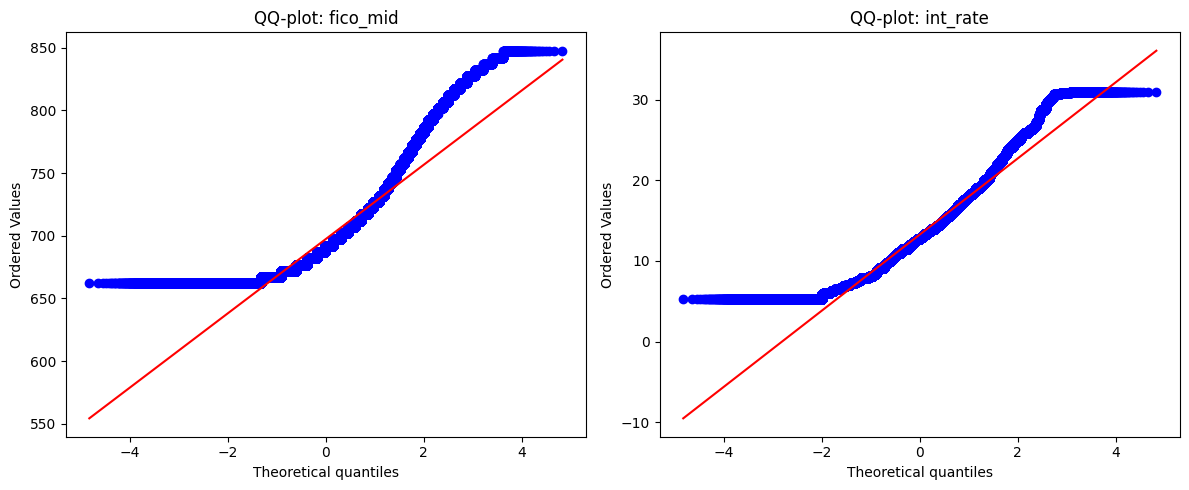

In [16]:
import scipy.stats as stats
import matplotlib.pyplot as plt

features = ['fico_mid', 'int_rate']

plt.figure(figsize=(12, 5))
for i, col in enumerate(features, 1):
    plt.subplot(1, 2, i)
    # QQ-plot 그리기
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f'QQ-plot: {col}')

plt.tight_layout()
plt.show()

### qq-plot 확인 결과 정규성을 만족하지 않으므로, 비모수 검정으로 진행

## Mann-Whitney U Test

In [26]:
# 실제 타겟값(y_train)을 기준으로 그룹 분리
group_default = X_train[y_train == 1] # 연체자
group_normal = X_train[y_train == 0]  # 정상인

for col in features:
    # Mann-Whitney U Test 수행 (중앙값 차이 검정)
    u_stat, p_val = stats.mannwhitneyu(group_default[col], group_normal[col], alternative='two-sided')
    
    print(f"[{col} 가설 검정 결과]")
    print(f"- 검정 통계량(U): {u_stat:.2f}")
    print(f"- p-value: {p_val:.4f}")
    
    if p_val < 0.05:
        print(f"👉 결론: p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다.")
        print(f"   (연체 여부에 따라 {col}의 차이가 통계적으로 유의미함)")
    else:
        print(f"👉 결론: 귀무가설을 기각할 수 없습니다. (통계적 차이 없음)")
    print("-" * 50)

[fico_mid 가설 검정 결과]
- 검정 통계량(U): 68935170228.00
- p-value: 0.0000
👉 결론: p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다.
   (연체 여부에 따라 fico_mid의 차이가 통계적으로 유의미함)
--------------------------------------------------
[int_rate 가설 검정 결과]
- 검정 통계량(U): 115310896374.00
- p-value: 0.0000
👉 결론: p-value가 유의수준 0.05보다 작으므로 귀무가설을 기각합니다.
   (연체 여부에 따라 int_rate의 차이가 통계적으로 유의미함)
--------------------------------------------------


In [25]:
import scipy.stats as stats

for col in ['fico_mid', 'int_rate']:
    g1 = X_train.loc[y_train == 1, col]
    g2 = X_train.loc[y_train == 0, col]
    
    u_stat, p_val = stats.mannwhitneyu(g1, g2)
    
    # RBC 계산
    rbc = 1 - (2 * u_stat / (len(g1) * len(g2)))
    
    # 절대값을 취해서 효과의 크기(강도)를 판정
    abs_rbc = abs(rbc)
    
    result_msg = ""
    if abs_rbc < 0.1:
        result_msg = "무시할 만한 효과"
    elif abs_rbc < 0.3:
        result_msg = "작은 효과"
    elif abs_rbc < 0.5:
        result_msg = "중간 효과"
    else:
        result_msg = "큰 효과"
        
    print(f"[{col}] RBC: {rbc:.4f} (절대값: {abs_rbc:.4f}) --> {result_msg}")

[fico_mid] RBC: 0.1819 (절대값: 0.1819) --> 작은 효과
[int_rate] RBC: -0.3685 (절대값: 0.3685) --> 중간 효과
